# Uvod u Pandas

Napomena: Ovi materijali su delimično bazirani na pandas tutorijalu Keith Galli-a ["Solving real world data science tasks with Python Pandas!"](https://github.com/KeithGalli/Pandas-Data-Science-Tasks). Takođe, dataset koji ćemo koristiti - [Sales dataset](https://github.com/KeithGalli/Pandas-Data-Science-Tasks/tree/master/SalesAnalysis/Sales_Data) - je preuzet iz pomenutog tutorijala.

## Učitavanje potrebnih biblioteka

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import squarify
import pypalettes

## Učitavanje podataka i upoznavanje sa podacima o prodaji za jedan mesec 

### Učitavanja podataka iz csv fajla

Podaci se nalaze u 'sales_data' direktorijumu, u okviru 'data' direktorijuma. 
Prvo ćemo kreirati DATA_DIR konstantu koja će sadržati putanju do direktorijuma sa podacima   

In [2]:
DATA_DIR = Path.cwd() / 'data/sales_data'

Zatim ćemo učitati podatke iz 'Sales_January_2019' csv fajla: 

In [3]:
df = pd.read_csv(DATA_DIR / 'Sales_January_2019.csv')

### Upoznavanje sa podacima 

Prikazati prvih 10 redova učitanog dataset-a

In [4]:
df.head(10)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,141234,iPhone,1,700,01/22/19 21:25,"944 Walnut St, Boston, MA 02215"
1,141235,Lightning Charging Cable,1,14.95,01/28/19 14:15,"185 Maple St, Portland, OR 97035"
2,141236,Wired Headphones,2,11.99,01/17/19 13:33,"538 Adams St, San Francisco, CA 94016"
3,141237,27in FHD Monitor,1,149.99,01/05/19 20:33,"738 10th St, Los Angeles, CA 90001"
4,141238,Wired Headphones,1,11.99,01/25/19 11:59,"387 10th St, Austin, TX 73301"
5,141239,AAA Batteries (4-pack),1,2.99,01/29/19 20:22,"775 Willow St, San Francisco, CA 94016"
6,141240,27in 4K Gaming Monitor,1,389.99,01/26/19 12:16,"979 Park St, Los Angeles, CA 90001"
7,141241,USB-C Charging Cable,1,11.95,01/05/19 12:04,"181 6th St, San Francisco, CA 94016"
8,141242,Bose SoundSport Headphones,1,99.99,01/01/19 10:30,"867 Willow St, Los Angeles, CA 90001"
9,141243,Apple Airpods Headphones,1,150,01/22/19 21:20,"657 Johnson St, San Francisco, CA 94016"


Utvrditi dimenzije data frame-a (broj redova i kolona)

In [5]:
df.shape

(9723, 6)

Ispisati listu naziva kolona data frame-a

In [6]:
df.columns.tolist()

['Order ID',
 'Product',
 'Quantity Ordered',
 'Price Each',
 'Order Date',
 'Purchase Address']

Utvrditi tip podatka svake kolone 

In [7]:
df.dtypes

Order ID            str
Product             str
Quantity Ordered    str
Price Each          str
Order Date          str
Purchase Address    str
dtype: object

Lep pregled tipova podataka u pandas-u, uključujući i njihovo mapiranje na python tipove podataka, može se naći, na primer, ovde: [https://pbpython.com/pandas_dtypes.html](https://pbpython.com/pandas_dtypes.html).

Kompletan skup informacija o data frame-u:

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9723 entries, 0 to 9722
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Order ID          9697 non-null   str  
 1   Product           9697 non-null   str  
 2   Quantity Ordered  9697 non-null   str  
 3   Price Each        9697 non-null   str  
 4   Order Date        9697 non-null   str  
 5   Purchase Address  9697 non-null   str  
dtypes: str(6)
memory usage: 455.9 KB


### Provera nedostajućih vrednosti

Prisustvo nedostajućih vrednosti u data frame-u može se ispitati primenom `isna()` metode:

In [9]:
df.isna().sum()

Order ID            26
Product             26
Quantity Ordered    26
Price Each          26
Order Date          26
Purchase Address    26
dtype: int64

#### Uklanjanje redova sa svim nedostajućim vrednostima

In [10]:
df.dropna(how="all", inplace=True)

In [11]:
df.isna().sum()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64

### Selekcija pojedinačnih kolona i redova i kreiranje podskupa podataka

Selekcija kolona i redova, odnosno kreiranje podskupa podataka, se može uraditi na različite načine, ali je preporučena praksa da se koriste `loc` ili `iloc` metode pandas Dataframe-a i to na sledeći način:

- Kada se selekcija redova i kolona vrši izbor na osnovu njihovog rednog broja, trebalo bi koristiti `iloc`

- Kada se izbor zasniva na uslovu koje redovi treba da zadovolje i/ili kolone treba izabrati na osnovu njihovih naziva, treba koristiti `loc` 

**Primer 1**: selektovati prve 3 kolone i prvih 6 redova

In [12]:
df.iloc[:6, :3]

,Order ID,Product,Quantity Ordered
0,141234,iPhone,1
1,141235,Lightning Charging Cable,1
2,141236,Wired Headphones,2
3,141237,27in FHD Monitor,1
4,141238,Wired Headphones,1
5,141239,AAA Batteries (4-pack),1


**Primer 2**: selektovati poslednjih 5 redova i 1., 2., i 5. kolonu

In [13]:
df.iloc[-5:, [0, 1, 4]]

,Order ID,Product,Order Date
9718,150497,20in Monitor,01/26/19 19:09
9719,150498,27in FHD Monitor,01/10/19 22:58
9720,150499,ThinkPad Laptop,01/21/19 14:31
9721,150500,AAA Batteries (4-pack),01/15/19 14:21
9722,150501,Google Phone,01/13/19 16:43


**Primer 3**: Selektovati kolone `Order ID`, `Order Date`, i `Purchase Address` za porudžbine iz Bostona

Tip: string vrednostima kolone možemo pristupiti preko `str` polja, tako da onda možemo pozvati bilo koju string metodu nad vrednostima kolone

In [14]:
df.loc[df["Purchase Address"].str.contains("Boston"), ["Order ID", "Order Date", "Purchase Address"]]

,Order ID,Order Date,Purchase Address
0,141234,01/22/19 21:25,"944 Walnut St, Boston, MA 02215"
17,141251,01/24/19 08:13,"414 Walnut St, Boston, MA 02215"
29,141263,01/11/19 23:33,"640 Spruce St, Boston, MA 02215"
31,141265,01/01/19 16:52,"853 Ridge St, Boston, MA 02215"
37,141271,01/30/19 10:51,"90 13th St, Boston, MA 02215"
...,...,...,...
9627,150409,01/10/19 02:38,"410 Forest St, Boston, MA 02215"
9660,150440,01/10/19 19:19,"82 Johnson St, Boston, MA 02215"
9666,150445,01/11/19 13:56,"147 Lincoln St, Boston, MA 02215"
9694,150473,01/10/19 09:09,"148 Hickory St, Boston, MA 02215"


**Primer 4**: Selektovati kolone `Order ID`, `Product`, i `Price Each` za porudžbine kod kojih naručena količina nije manja od 3

Napomena: Primetite da iako bi kolona `Quantity Ordered` trebalo da sadrži numeričke podatke, njene vrednosti su zapisane kao stringovi: 

In [15]:
df["Quantity Ordered"].tolist()[0]

'1'

Tako da je potrebno da prvo transformišemo `Quantity Ordered` kolonu u numerički tip:

In [16]:
df["Quantity Ordered"] = pd.to_numeric(df["Quantity Ordered"], errors="coerce")

In [17]:
df["Quantity Ordered"].tolist()[0]

1.0

Sada se možemo vratiti selekciji redova i kolona:

In [18]:
df.loc[df["Quantity Ordered"] >= 3, ["Order ID", "Product", "Price Each"]]

,Order ID,Product,Price Each
12,141246,AAA Batteries (4-pack),2.99
52,141285,AAA Batteries (4-pack),2.99
58,141290,AA Batteries (4-pack),3.84
73,141305,AAA Batteries (4-pack),2.99
84,141316,AAA Batteries (4-pack),2.99
...,...,...,...
9513,150299,AA Batteries (4-pack),3.84
9590,150372,AAA Batteries (4-pack),2.99
9636,150417,Wired Headphones,11.99
9659,150439,Wired Headphones,11.99


## Učitavanje podataka o prodaji za sve mesece u 2019. god. i integracija mesečnih podataka o prodaji u jedan data frame

Potrebno je da učitamo podatke o prodaji iz svih csv fajlova u 'sales_data' direktorijumu (po jedan fajl za svaki mesec 2019. god.)

Prvo ćemo videti kako možemo da selektujemo samo .csv fajlove iz datog direktorijuma:

In [19]:
def get_csv_files(fpath: Path) -> list:
    if not fpath.is_dir():
        raise RuntimeError("Ovo nije direktorijum !")

    fajlovi = []
    for fajl in fpath.iterdir():
        if not fajl.is_dir() and fajl.suffix == ".csv":
            fajlovi.append(fajl)

    return fajlovi

In [20]:
get_csv_files(DATA_DIR)

[WindowsPath('D:/projekti/python/pandas_labs/data/sales_data/Sales_April_2019.csv'),
 WindowsPath('D:/projekti/python/pandas_labs/data/sales_data/Sales_August_2019.csv'),
 WindowsPath('D:/projekti/python/pandas_labs/data/sales_data/Sales_December_2019.csv'),
 WindowsPath('D:/projekti/python/pandas_labs/data/sales_data/Sales_February_2019.csv'),
 WindowsPath('D:/projekti/python/pandas_labs/data/sales_data/Sales_January_2019.csv'),
 WindowsPath('D:/projekti/python/pandas_labs/data/sales_data/Sales_July_2019.csv'),
 WindowsPath('D:/projekti/python/pandas_labs/data/sales_data/Sales_June_2019.csv'),
 WindowsPath('D:/projekti/python/pandas_labs/data/sales_data/Sales_March_2019.csv'),
 WindowsPath('D:/projekti/python/pandas_labs/data/sales_data/Sales_May_2019.csv'),
 WindowsPath('D:/projekti/python/pandas_labs/data/sales_data/Sales_November_2019.csv'),
 WindowsPath('D:/projekti/python/pandas_labs/data/sales_data/Sales_October_2019.csv'),
 WindowsPath('D:/projekti/python/pandas_labs/data/sales

Sada ćemo, u petlji, uzimati jedan po jedan csv fajl, učitati podatke iz njega i dodati učitane podatke u jedan data frame koji sadrži podatke o prodaji za celu godinu. Za spajanje dva data frame-a, koristimo funkciju `pd.concat`:

In [21]:
all_sales = pd.DataFrame()
for csv_fajl in get_csv_files(DATA_DIR):
    all_sales = pd.concat([all_sales, pd.read_csv(csv_fajl)])

In [22]:
all_sales.shape

(186850, 6)

### Pregled učitanih i integrisanih podataka o prodaji

In [23]:
all_sales.info()

<class 'pandas.DataFrame'>
Index: 186850 entries, 0 to 11685
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Order ID          186305 non-null  str  
 1   Product           186305 non-null  str  
 2   Quantity Ordered  186305 non-null  str  
 3   Price Each        186305 non-null  str  
 4   Order Date        186305 non-null  str  
 5   Purchase Address  186305 non-null  str  
dtypes: str(6)
memory usage: 10.0 MB


Obratite pažnju na razliku između broja redova i vrednosti indeksa. Deluje kao da se učitane vrednosti indeksa ponavljaju. Da posle ne bismo imali problema, potrebno je da sredimo, odnosno resetujemo indeks:

In [24]:
all_sales.reset_index(drop=True, inplace=True)

In [25]:
all_sales.index

RangeIndex(start=0, stop=186850, step=1)

Preimenovaćemo data frame, da smanjimo kucanje: 

In [26]:
sales = all_sales

Primetite da smo samo dali novo ime (referencu) postojećem objektu, odnosno, nismo kreirali novi data frame objekat, već samo novu referencu na postojeći

To možemo da potvrdimo:

In [27]:
id(sales) == id(all_sales)

True

In [28]:
sales is all_sales

True

Ako bismo hteli da kreiramo novi pd.DataFrame objekat, identičan postojećem, bilo bi potrebno da uradimo sledeće:

In [29]:
tmp = all_sales.copy()

In [30]:
tmp is all_sales

False

In [31]:
del tmp

## Sređivanje podataka (data wrangling) 

In [32]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Order ID          186305 non-null  str  
 1   Product           186305 non-null  str  
 2   Quantity Ordered  186305 non-null  str  
 3   Price Each        186305 non-null  str  
 4   Order Date        186305 non-null  str  
 5   Purchase Address  186305 non-null  str  
dtypes: str(6)
memory usage: 8.6 MB


Veliki broj kolona je tipa object, uključujući i one za koje to ne bismo očekivali - konkretno, kolone `Quantity Ordered`, `Price Each` i `Order Date`. To moramo promeniti, ali prvo ćemo se pozabaviti nedostajućim vrednostima.

### Uklanjanje observacija sa nedostajućim vrednostima

Izlaz f. `info()` sugeriše da nedostaju kompletni redovi podataka, odnosno da imamo observacije sa svim nedostajućim vrednostima. Uzećemo uzorak da to proverimo:

In [33]:
sales.loc[sales["Order ID"].isna(),].sample(10)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
48120,NaN,NaN,NaN,NaN,NaN,NaN
76170,NaN,NaN,NaN,NaN,NaN,NaN
11881,NaN,NaN,NaN,NaN,NaN,NaN
169516,NaN,NaN,NaN,NaN,NaN,NaN
69038,NaN,NaN,NaN,NaN,NaN,NaN
29257,NaN,NaN,NaN,NaN,NaN,NaN
17446,NaN,NaN,NaN,NaN,NaN,NaN
166558,NaN,NaN,NaN,NaN,NaN,NaN
136680,NaN,NaN,NaN,NaN,NaN,NaN
9592,NaN,NaN,NaN,NaN,NaN,NaN


Uklonićemo observacije (redove) sa svim nedostajućim vrednostima

In [34]:
sales.dropna(how="all", inplace=True)

In [35]:
sales.isna().sum()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64

### Transformacija varijabli *Quantity Ordered* i *Price Each* u numeričke, a *Order Date* u datetime

Korisne smernice za ove oblike transformacije varijabli mogu se naći u odgovorima na [ovo pitanje na StackOverflow-u](https://stackoverflow.com/questions/15891038/change-column-type-in-pandas)

Prvo ćemo pokušati da transformišemo `Quantity Ordered` u numeričku kolonu

In [36]:
try:
    sales["Quantity_Ordered"] = pd.to_numeric(sales["Quantity Ordered"])
except ValueError as ve:
    print(ve)

Unable to parse string "Quantity Ordered" at position 517


Pogledaćemo red (observaciju) gde je došlo do greške:

In [37]:
sales.iloc[517,]

Order ID                    Order ID
Product                      Product
Quantity Ordered    Quantity Ordered
Price Each                Price Each
Order Date                Order Date
Purchase Address    Purchase Address
Name: 519, dtype: str

Red koji je uslovio grešku očigleno sadrži pogrešno unete podatke koji nam nisu potrebni. Tako da ćemo izvršiti konverziju u numerički tip i, pri tome, vrednosti koje ne mogu da se transformišu u numeričke zameniti sa NaN (tj. označiti podatke kao nedostajuće)

In [38]:
sales["Quantity_Ordered"] = pd.to_numeric(sales["Quantity Ordered"], errors="coerce")

Utvrdićemo broj i procenat uvedenih nedostajućih vrednosti u koloni `Quantity_Ordered`:

In [39]:
sales.Quantity_Ordered.isna().sum()

np.int64(355)

In [40]:
# sales.Quantity_Ordered.isna().sum() / sales.shape[0] * 100

sales.Quantity_Ordered.isna().mean() * 100

np.float64(0.19054775770913288)

Na isti način ćemo transformisati `Price Each` kolonu:

In [41]:
sales["Price_Each"] = pd.to_numeric(sales["Price Each"], errors="coerce")

In [42]:
sales.Price_Each.isna().sum()

np.int64(355)

In [43]:
sales.dropna(how="any", inplace=True, subset=["Price_Each", "Quantity_Ordered"])

Izbacićemo redove gde su naručena količina ili jedinična cena nepoznati (NaN)

In [44]:
sales.isna().sum().sum()

np.int64(0)

In [45]:
sales.shape

(185950, 8)

Proverićemo veličinu data frame-a nakon uklanjanja redova sa svim nedostajućim vrednostima:

In [46]:
sales["Order Date"].sample(10)

174345    10/07/19 10:13
145266    11/22/19 10:06
127505    05/27/19 14:27
78251     07/15/19 21:51
109041    03/28/19 20:35
128101    05/30/19 13:56
105514    03/17/19 18:18
158994    10/18/19 12:57
61859     02/01/19 23:42
29572     08/31/19 07:06
Name: Order Date, dtype: str

Konačno, transformisaćemo `Order Date` u datetime tip

In [47]:
sales["Order_Date"] = pd.to_datetime(sales["Order Date"], errors="coerce", format="%m/%d/%y %H:%M")

In [48]:
sales[["Order Date", "Order_Date"]].sample(10)

,Order Date,Order_Date
129908,05/20/19 21:25,2019-05-20 21:25:00
55846,02/04/19 20:24,2019-02-04 20:24:00
130702,05/03/19 20:14,2019-05-03 20:14:00
123177,05/27/19 14:18,2019-05-27 14:18:00
11239,04/23/19 23:42,2019-04-23 23:42:00
152351,11/11/19 20:22,2019-11-11 20:22:00
86077,07/21/19 19:26,2019-07-21 19:26:00
125099,05/20/19 17:58,2019-05-20 17:58:00
83789,07/13/19 14:25,2019-07-13 14:25:00
3204,04/24/19 17:41,2019-04-24 17:41:00


In [49]:
sales.info()

<class 'pandas.DataFrame'>
Index: 185950 entries, 0 to 186849
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185950 non-null  str           
 1   Product           185950 non-null  str           
 2   Quantity Ordered  185950 non-null  str           
 3   Price Each        185950 non-null  str           
 4   Order Date        185950 non-null  str           
 5   Purchase Address  185950 non-null  str           
 6   Quantity_Ordered  185950 non-null  float64       
 7   Price_Each        185950 non-null  float64       
 8   Order_Date        185950 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(2), str(6)
memory usage: 14.2 MB


Nakon ovih transformacija, proverićemo kako sad izgledaju tipovi podataka u data frame-u:

In [50]:
sales.drop(columns=["Quantity Ordered", "Price Each", "Order Date"], inplace=True)

Uklonićemo kolone koje više nisu potrebne:

In [51]:
sales.columns.tolist()

['Order ID',
 'Product',
 'Purchase Address',
 'Quantity_Ordered',
 'Price_Each',
 'Order_Date']

### Dodavanje *Purchase_City* kolone

Sad ćemo videti kako možemo da napravimo novu kolonu od postojeće.

Pošto će nam kasnije biti potrebno da uporedimo prodaju po gradovima, dodaćemo kolonu sa nazivom grada u kome je porudžbina napravljena. Nakon imena grada treba da stoji oznaka države, data u zagradi (npr. „Atlanta (GA)“), da bi se omogućilo razlikovanje gradova sa istim nazivima.   

Uzećemo uzorak vrednosti kolone `Purchase Address` kako bismo se upoznali sa formatom u kome su adrese zapisane:

In [52]:
sales["Purchase Address"].sample(10)

21528                940 14th St, Portland, OR 97035
23262                  121 9th St, Seattle, WA 98101
47492     989 Washington St, San Francisco, CA 94016
78622           608 Center St, Los Angeles, CA 90001
5121           714 North St, San Francisco, CA 94016
26141           949 Main St, San Francisco, CA 94016
113452            606 Hickory St, Portland, OR 97035
160289        246 Chestnut St, Los Angeles, CA 90001
51616                  314 11th St, Boston, MA 02215
171807             108 Chestnut St, Boston, MA 02215
Name: Purchase Address, dtype: str

Prvo ćemo kreirati funkciju koja izdvaja grad (i oznaku države) iz kolone `Purchase Address`: 

In [53]:
def get_city_state(address: str) -> str:
    _, city, state = address.split(",")
    state, _ = state.split()
    return f"{city.strip()} ({state})"

In [54]:
get_city_state(sales["Purchase Address"][0])

'Dallas (TX)'

Zatim ćemo koristeći `apply` metodu, primeniti `get_city_and_state()` f. na svaku vrednost serije `Purchase Address`. Ali, prvo ćemo isprobati na uzorku adresa:

In [55]:
sales["Purchase Address"].sample(10).apply(get_city_state)

62867     San Francisco (CA)
16592            Austin (TX)
109574    New York City (NY)
10618     San Francisco (CA)
64119           Seattle (WA)
26699       Los Angeles (CA)
130517      Los Angeles (CA)
10642       Los Angeles (CA)
36095     San Francisco (CA)
153571           Boston (MA)
Name: Purchase Address, dtype: str

Sad možemo primenti funkciju na sve vrednosti kolone `Purchase Address`, kako bi kreirali novu kolonu - `Purchase_City`

In [56]:
sales["Purchase_City"] = sales["Purchase Address"].apply(get_city_state)

In [57]:
sales[["Purchase Address", "Purchase_City"]].sample(20)

,Purchase Address,Purchase_City
4633,"534 Park St, Atlanta, GA 30301",Atlanta (GA)
127565,"187 Ridge St, New York City, NY 10001",New York City (NY)
185854,"10 Spruce St, Los Angeles, CA 90001",Los Angeles (CA)
106891,"998 Dogwood St, San Francisco, CA 94016",San Francisco (CA)
162952,"986 Main St, Los Angeles, CA 90001",Los Angeles (CA)
10399,"184 10th St, San Francisco, CA 94016",San Francisco (CA)
9383,"309 South St, Seattle, WA 98101",Seattle (WA)
176945,"493 Jefferson St, Los Angeles, CA 90001",Los Angeles (CA)
92452,"572 Elm St, Dallas, TX 75001",Dallas (TX)
174568,"58 Ridge St, Los Angeles, CA 90001",Los Angeles (CA)


Sačuvaćemo transformisani dataset u fajl:

In [58]:
processed_data_dir = DATA_DIR / 'processed_data'
processed_data_dir.mkdir(parents=True, exist_ok=True)

In [59]:
sales.to_csv(processed_data_dir / "sales_2019.csv", index=False)

## Eksploratorna analiza podataka

Sada ćemo pokušati da odgovorimo na neka pitanja vezana za ostvarenu prodaju u 2019. godini, kroz eksploratornu analizu `sales` dataseta

In [60]:
sales = pd.read_csv(DATA_DIR / 'processed_data/sales_2019.csv', parse_dates=["Order_Date"])

In [61]:
sales.head(10)

,Order ID,Product,Purchase Address,Quantity_Ordered,Price_Each,Order_Date,Purchase_City
0,176558,USB-C Charging Cable,"917 1st St, Dallas, TX 75001",2.0,11.95,2019-04-19 08:46:00,Dallas (TX)
1,176559,Bose SoundSport Headphones,"682 Chestnut St, Boston, MA 02215",1.0,99.99,2019-04-07 22:30:00,Boston (MA)
2,176560,Google Phone,"669 Spruce St, Los Angeles, CA 90001",1.0,600.00,2019-04-12 14:38:00,Los Angeles (CA)
3,176560,Wired Headphones,"669 Spruce St, Los Angeles, CA 90001",1.0,11.99,2019-04-12 14:38:00,Los Angeles (CA)
4,176561,Wired Headphones,"333 8th St, Los Angeles, CA 90001",1.0,11.99,2019-04-30 09:27:00,Los Angeles (CA)
5,176562,USB-C Charging Cable,"381 Wilson St, San Francisco, CA 94016",1.0,11.95,2019-04-29 13:03:00,San Francisco (CA)
6,176563,Bose SoundSport Headphones,"668 Center St, Seattle, WA 98101",1.0,99.99,2019-04-02 07:46:00,Seattle (WA)
7,176564,USB-C Charging Cable,"790 Ridge St, Atlanta, GA 30301",1.0,11.95,2019-04-12 10:58:00,Atlanta (GA)
8,176565,Macbook Pro Laptop,"915 Willow St, San Francisco, CA 94016",1.0,1700.00,2019-04-24 10:38:00,San Francisco (CA)
9,176566,Wired Headphones,"83 7th St, Boston, MA 02215",1.0,11.99,2019-04-08 14:05:00,Boston (MA)


In [62]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185950 non-null  int64         
 1   Product           185950 non-null  str           
 2   Purchase Address  185950 non-null  str           
 3   Quantity_Ordered  185950 non-null  float64       
 4   Price_Each        185950 non-null  float64       
 5   Order_Date        185950 non-null  datetime64[us]
 6   Purchase_City     185950 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 9.9 MB


### Zadatak 1. Koji je bio najbolji mesec za prodaju? Kolika zarada je ostvarena tog meseca?

Da bismo odgovorili na ovo pitanje, potrebno je da:
- izračunamo ukupan prihod po porudžbini
- izdvojimo mesec iz datuma porudžbine, tako da možemo grupisati porudžbine na mesečnoj osnovi
- izračunamo ukupan prihod na mesečnom nivou

**Korak 1**: Izračunavanje ukupnog prihoda po porudžbini

In [63]:
sales["Total_Revenue"] = sales.Quantity_Ordered * sales.Price_Each

In [64]:
sales[["Total_Revenue", "Quantity_Ordered", "Price_Each"]].sample(10)

,Total_Revenue,Quantity_Ordered,Price_Each
144688,99.99,1.0,99.99
148577,600.00,1.0,600.00
123704,150.00,1.0,150.00
72928,600.00,1.0,600.00
106877,999.99,1.0,999.99
79724,99.99,1.0,99.99
50524,1700.00,1.0,1700.00
108946,11.95,1.0,11.95
4352,23.90,2.0,11.95
107709,11.95,1.0,11.95


**Korak 2**: Izdvajanje meseca iz datuma porudžbine (`Order_Date`)

S obzirom da je `Order_Date` pandas serija tipa datetime, možemo koristiti `dt` da bismo dobili pristup svakoj vrednosti u seriji kao datetime objektu. 

Kad imamo pristup datumu porudžbine kao datetime objektu, možemo uzeti bilo koji element datuma (godina, mesec, dan, itd.) i vremena porudžbine kroz odgovarajuća polja objekta.

In [65]:
sales["Order_Month"] = sales.Order_Date.dt.month

In [66]:
sales[["Order_Date", "Order_Month"]].sample(10)

,Order_Date,Order_Month
167966,2019-10-10 22:19:00,10
106996,2019-03-30 16:25:00,3
13256,2019-04-01 13:02:00,4
161165,2019-10-01 06:05:00,10
174365,2019-09-29 20:50:00,9
48905,2019-12-05 14:08:00,12
82870,2019-07-11 06:50:00,7
115086,2019-03-14 16:42:00,3
98743,2019-06-01 20:23:00,6
82477,2019-07-14 19:12:00,7


**Korak 3**: Izračunavanje ukupnog prihoda za svaki mesec

In [67]:
revenue_per_month = sales.groupby("Order_Month").Total_Revenue.sum()
revenue_per_month

Order_Month
1     1822256.73
2     2202022.42
3     2807100.38
4     3390670.24
5     3152606.75
6     2577802.26
7     2647775.76
8     2244467.88
9     2097560.13
10    3736726.88
11    3199603.20
12    4613443.34
Name: Total_Revenue, dtype: float64

Sortiranje rezultata u opdajućem redosledu ukupnog mesečnog prihoda

In [68]:
revenue_per_month.sort_values(ascending=False)

Order_Month
12    4613443.34
10    3736726.88
4     3390670.24
11    3199603.20
5     3152606.75
3     2807100.38
7     2647775.76
6     2577802.26
8     2244467.88
2     2202022.42
9     2097560.13
1     1822256.73
Name: Total_Revenue, dtype: float64

Možemo predstaviti i sagledati mesečne prihode na (bar) plotu, pošto vizuelno predstavljanje podataka često olakšava razumevanje trendova koji mogu biti prisutni u podacima.

Za kreiranje plota, koristićemo Matplotlib bibliotetku, čiju dokumentaciju možete naći [ovde](https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html), dok [ovaj primer](https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_colors.html#sphx-glr-gallery-lines-bars-and-markers-bar-colors-py) može poslužiti kao dobra polazna osnova za konkretni zadatak vizuelizacije koji imamo.

Napomena: Na [ovom GitHub repozitorijumu](https://github.com/matplotlib/cheatsheets) možete naći dobro urađene cheat sheets i savete za korišćenje Mathplotlib bliblioteke.

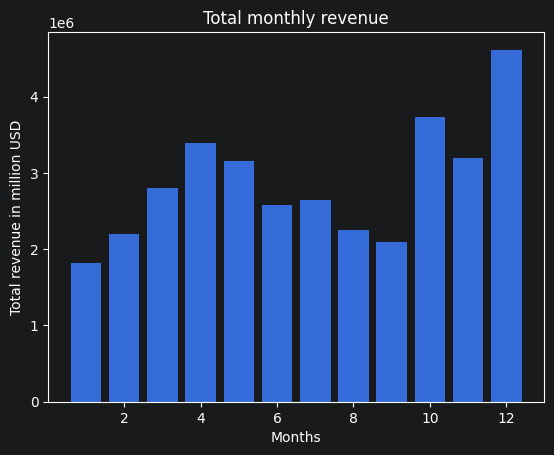

In [69]:
fig, ax = plt.subplots()

x = revenue_per_month.index.tolist()
y = revenue_per_month.values.tolist()

ax.bar(x, y)

ax.set_xlabel("Months")
ax.set_ylabel("Total revenue in million USD")
ax.set_title("Total monthly revenue")

plt.show()

### Zadatak 2. Iz kog grada je naručeno najviše proizvoda?

Za potrebe ovog zadatka, grupisaćemo porudžbine prema gradu iz koga dolaze:

In [70]:
sales.head(10)

,Order ID,Product,Purchase Address,Quantity_Ordered,Price_Each,Order_Date,Purchase_City,Total_Revenue,Order_Month
0,176558,USB-C Charging Cable,"917 1st St, Dallas, TX 75001",2.0,11.95,2019-04-19 08:46:00,Dallas (TX),23.90,4
1,176559,Bose SoundSport Headphones,"682 Chestnut St, Boston, MA 02215",1.0,99.99,2019-04-07 22:30:00,Boston (MA),99.99,4
2,176560,Google Phone,"669 Spruce St, Los Angeles, CA 90001",1.0,600.00,2019-04-12 14:38:00,Los Angeles (CA),600.00,4
3,176560,Wired Headphones,"669 Spruce St, Los Angeles, CA 90001",1.0,11.99,2019-04-12 14:38:00,Los Angeles (CA),11.99,4
4,176561,Wired Headphones,"333 8th St, Los Angeles, CA 90001",1.0,11.99,2019-04-30 09:27:00,Los Angeles (CA),11.99,4
5,176562,USB-C Charging Cable,"381 Wilson St, San Francisco, CA 94016",1.0,11.95,2019-04-29 13:03:00,San Francisco (CA),11.95,4
6,176563,Bose SoundSport Headphones,"668 Center St, Seattle, WA 98101",1.0,99.99,2019-04-02 07:46:00,Seattle (WA),99.99,4
7,176564,USB-C Charging Cable,"790 Ridge St, Atlanta, GA 30301",1.0,11.95,2019-04-12 10:58:00,Atlanta (GA),11.95,4
8,176565,Macbook Pro Laptop,"915 Willow St, San Francisco, CA 94016",1.0,1700.00,2019-04-24 10:38:00,San Francisco (CA),1700.00,4
9,176566,Wired Headphones,"83 7th St, Boston, MA 02215",1.0,11.99,2019-04-08 14:05:00,Boston (MA),11.99,4


In [71]:
sales_per_city = sales.groupby("Purchase_City").Quantity_Ordered.sum()
sales_per_city

Purchase_City
Atlanta (GA)          16602.0
Austin (TX)           11153.0
Boston (MA)           22528.0
Dallas (TX)           16730.0
Los Angeles (CA)      33289.0
New York City (NY)    27932.0
Portland (ME)          2750.0
Portland (OR)         11303.0
San Francisco (CA)    50239.0
Seattle (WA)          16553.0
Name: Quantity_Ordered, dtype: float64

In [72]:
sales_per_city_df = sales_per_city.to_frame()
sales_per_city_df

,Quantity_Ordered
Purchase_City,
Atlanta (GA),16602.0
Austin (TX),11153.0
Boston (MA),22528.0
Dallas (TX),16730.0
Los Angeles (CA),33289.0
New York City (NY),27932.0
Portland (ME),2750.0
Portland (OR),11303.0
San Francisco (CA),50239.0


In [73]:
sales_per_city_df.reset_index(inplace=True)
sales_per_city_df

,Purchase_City,Quantity_Ordered
0,Atlanta (GA),16602.0
1,Austin (TX),11153.0
2,Boston (MA),22528.0
3,Dallas (TX),16730.0
4,Los Angeles (CA),33289.0
5,New York City (NY),27932.0
6,Portland (ME),2750.0
7,Portland (OR),11303.0
8,San Francisco (CA),50239.0
9,Seattle (WA),16553.0


In [74]:
def separate_city_and_state(city_state):
    city, state = city_state.rsplit(maxsplit=1)
    state = state.strip("()")
    return city, state


separate_city_and_state(sales_per_city_df.Purchase_City[0])

('Atlanta', 'GA')

In [75]:
sales_per_city_df["City"] = sales_per_city_df.Purchase_City.apply(
    lambda city_state: separate_city_and_state(city_state)[0])
sales_per_city_df["State"] = sales_per_city_df.Purchase_City.apply(
    lambda city_state: separate_city_and_state(city_state)[1])

sales_per_city_df.head(10)

,Purchase_City,Quantity_Ordered,City,State
0,Atlanta (GA),16602.0,Atlanta,GA
1,Austin (TX),11153.0,Austin,TX
2,Boston (MA),22528.0,Boston,MA
3,Dallas (TX),16730.0,Dallas,TX
4,Los Angeles (CA),33289.0,Los Angeles,CA
5,New York City (NY),27932.0,New York City,NY
6,Portland (ME),2750.0,Portland,ME
7,Portland (OR),11303.0,Portland,OR
8,San Francisco (CA),50239.0,San Francisco,CA
9,Seattle (WA),16553.0,Seattle,WA


Zatim ćemo odrediti maksimalnu (ukupnu) naručenu količinu, kao i grad na koji se taj maksimum odnosi:

In [76]:
sales_per_city.max()

np.float64(50239.0)

In [77]:
sales_per_city.idxmax()

'San Francisco (CA)'

Na kraju, prikazaćemo rezultate vizuelno primenom bar plota.

Napomena: za fina podešavanja prikaza plota, brojne korisne metode se mogu naći u [ovom delu](https://matplotlib.org/stable/api/axes_api.html) Matplotlib dokumentacije

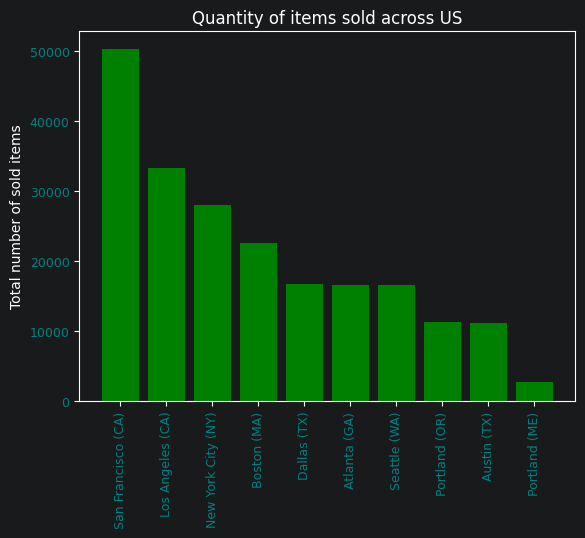

In [78]:
sales_per_city.sort_values(ascending=False, inplace=True)

fig, ax = plt.subplots()

x = sales_per_city.index
y = sales_per_city

ax.bar(x, y, color="green")

ax.tick_params(axis="x", labelrotation=90, labelsize=9, labelcolor="teal")
ax.tick_params(axis="y", labelsize=9, labelcolor="teal")

ax.set_ylabel("Total number of sold items")
ax.set_title("Quantity of items sold across US")

plt.show()

#### Zadatak Viz 1: Treemap plot

Prikazati ukupne naručene količine na nivou pojedinačnih gradova i država primenom tzv. [*treeemap* plota](https://python-graph-gallery.com/treemap/) koji se može jednostavno kreirati primenom **[squarify](https://python-graph-gallery.com/590-advanced-treemap/)** biblioteke.
Predstaviti istom bojom gradove koji pripadaju istoj državi (tj., polja treemap plota koja se odnose na gradove iz iste države bi trebalo da budu iste boje).

Za rad sa paletama boja, koristićemo **[pypalettes](https://github.com/JosephBARBIERDARNAL/pypalettes)** biblioteku koja sadrži kolekciju od preko 2500 paleta boja i omogućuje jednostavno pretraživanje i korišćenje tih paleta. Sve potrebno za osnovno korišćenje ove biblioteke je lepo predstavljeno ovde: [https://python-graph-gallery.com/color-palette-finder/](https://python-graph-gallery.com/color-palette-finder/)

In [79]:
state_num_labes, unique_states = pd.factorize(sales_per_city_df.State)

print(state_num_labes)
print(unique_states)

[0 1 2 1 3 4 5 6 3 7]
Index(['GA', 'TX', 'MA', 'CA', 'NY', 'ME', 'OR', 'WA'], dtype='str')


In [80]:
cmap = pypalettes.load_cmap("Abbott")
colors = [cmap(code) for code in state_num_labes]

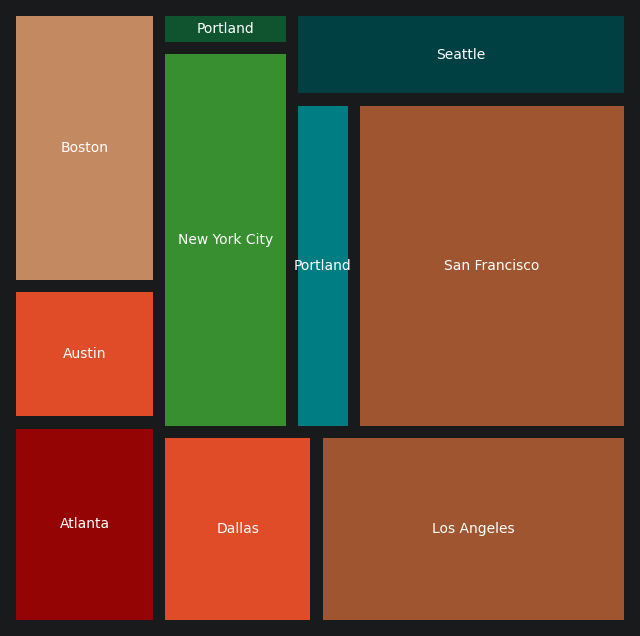

In [81]:
_, ax = plt.subplots(figsize=(8, 8))

ax.set_axis_off()

squarify.plot(
    sizes=sales_per_city_df.Quantity_Ordered,
    label=sales_per_city_df.City,
    color=colors,
    text_kwargs={"color": "white"},
    pad=True,
    ax=ax
)

plt.show()

### Zadatak 3. Kada, tokom dana, klijenti imaju tendenciju da naprave najvrednije porudžbine?

Da bismo odgovorili na ovo pitanje, potrebno je da izdvojimo sate iz `Order_Date` kolone i utvrdimo prosečnu ukupnu cenu porudžbine za svaki sat u toku dana

**Korak 1**: Kreiranje 'Order_Hour' kolone

In [82]:
sales["Order_Hour"] = sales.Order_Date.dt.hour

In [83]:
sales[["Order_Date", "Order_Hour"]].sample(10)

,Order_Date,Order_Hour
168064,2019-10-08 12:16:00,12
89749,2019-07-10 19:05:00,19
170081,2019-10-17 12:36:00,12
149005,2019-11-09 23:53:00,23
124960,2019-05-13 07:00:00,7
26319,2019-08-10 19:00:00,19
163201,2019-10-19 13:06:00,13
86269,2019-07-24 20:06:00,20
118372,2019-03-05 16:54:00,16
119415,2019-03-18 00:18:00,0


**Korak 2**: Grupisanje narudžbina na osnovu `Order_Hour` i izračuvanje prosečne vrednosti `Total_Price` varijable za svaku grupu

In [84]:
sales_per_hour = sales.groupby("Order_Hour").Total_Revenue.mean()
sales_per_hour

Order_Hour
0     182.537409
1     196.113566
2     188.939212
3     175.400590
4     190.469567
5     174.625148
6     180.545125
7     185.702847
8     190.592866
9     187.360606
10    177.657782
11    185.368644
12    184.064617
13    177.705483
14    189.700722
15    190.815686
16    183.416921
17    195.372200
18    180.728689
19    186.977028
20    186.597664
21    186.979293
22    182.220495
23    187.936963
Name: Total_Revenue, dtype: float64

Odredićemo najveću prosečnu vrednost prodaje i sat u toku dana na koji se ona odnosi:

In [85]:
sales_per_hour.max()

np.float64(196.1135659574468)

In [86]:
sales_per_hour.idxmax()

np.int32(1)

Prikaz rezultata u formi linijskog plota

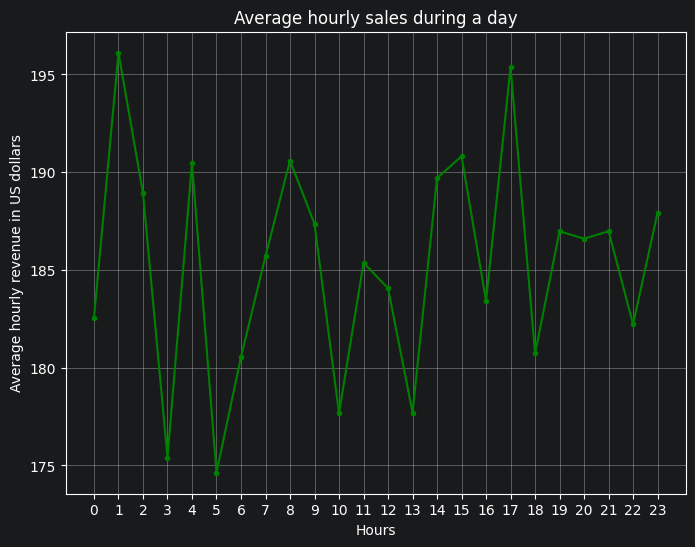

In [87]:
x = sales_per_hour.index
y = sales_per_hour

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x, y, marker=".", color="green")

ax.set_title("Average hourly sales during a day")
ax.set_xlabel("Hours")
ax.set_xticks(range(0, 24))
ax.set_ylabel("Average hourly revenue in US dollars")

ax.grid(visible=True, which="major", axis="both", color="lightgray")

plt.show()

### Zadatak 4. Odrediti top 5 proizvoda po obimu prodaje, kao i top 5 po ostvarenom prihodu tokom 2019. god.

Prvo ćemo utvrditi koliko različitih proizvoda postoji i koliko često su bili naručeni

In [88]:
sales.Product.unique().tolist()

['USB-C Charging Cable',
 'Bose SoundSport Headphones',
 'Google Phone',
 'Wired Headphones',
 'Macbook Pro Laptop',
 'Lightning Charging Cable',
 '27in 4K Gaming Monitor',
 'AA Batteries (4-pack)',
 'Apple Airpods Headphones',
 'AAA Batteries (4-pack)',
 'iPhone',
 'Flatscreen TV',
 '27in FHD Monitor',
 '20in Monitor',
 'LG Dryer',
 'ThinkPad Laptop',
 'Vareebadd Phone',
 'LG Washing Machine',
 '34in Ultrawide Monitor']

In [89]:
sales.Product.nunique()

19

In [90]:
sales.Product.value_counts()

Product
USB-C Charging Cable          21903
Lightning Charging Cable      21658
AAA Batteries (4-pack)        20641
AA Batteries (4-pack)         20577
Wired Headphones              18882
Apple Airpods Headphones      15549
Bose SoundSport Headphones    13325
27in FHD Monitor               7507
iPhone                         6842
27in 4K Gaming Monitor         6230
34in Ultrawide Monitor         6181
Google Phone                   5525
Flatscreen TV                  4800
Macbook Pro Laptop             4724
ThinkPad Laptop                4128
20in Monitor                   4101
Vareebadd Phone                2065
LG Washing Machine              666
LG Dryer                        646
Name: count, dtype: int64

Gornja pandas serija nam daje broj porudžbina u kojima se pojavio proizvod, ali ne govori nam o količinama koje su naručene.

Potrebno je da za svaki proizvod, uzmemo ukupnu naručenu količinu i ukupnu cenu za sve porudžbine koje se odnose na taj proizvod:

In [91]:
sales_per_product = sales.groupby("Product")[["Quantity_Ordered", "Total_Revenue"]].sum()
sales_per_product

,Quantity_Ordered,Total_Revenue
Product,,
20in Monitor,4129.0,454148.71
27in 4K Gaming Monitor,6244.0,2435097.56
27in FHD Monitor,7550.0,1132424.50
34in Ultrawide Monitor,6199.0,2355558.01
AA Batteries (4-pack),27635.0,106118.40
AAA Batteries (4-pack),31017.0,92740.83
Apple Airpods Headphones,15661.0,2349150.00
Bose SoundSport Headphones,13457.0,1345565.43
Flatscreen TV,4819.0,1445700.00


Odredićemo top 5 proizvoda po ostvarenom obimu prodaje:

In [92]:
# sales_per_product.sort_values(by="Quantity_Ordered", ascending=False).head(5)
sales_per_product.sort_values(by="Quantity_Ordered", ascending=False).head(5).index.tolist()

['AAA Batteries (4-pack)',
 'AA Batteries (4-pack)',
 'USB-C Charging Cable',
 'Lightning Charging Cable',
 'Wired Headphones']

Takođe, top 5 proizvoda po ostvarenom prihodu:

In [93]:
# sales_per_product.sort_values(by="Total_Revenue", ascending=False).head(5)
sales_per_product.sort_values(by="Total_Revenue", ascending=False).head(5).index.tolist()

['Macbook Pro Laptop',
 'iPhone',
 'ThinkPad Laptop',
 'Google Phone',
 '27in 4K Gaming Monitor']

Predstavićemo ove rezultate i vizuelno. Konkretno, napravićemo dve horizontalna bar plota, jedan pored drugog, pri čemu će prvi prikazivati ukupan prihod po proizvodu, a drugi prodatu količinu proizvoda. Sortiraćemo plotove na osnovu ukupnog prihoda, tako da proizvodi sa najvećim prihodom budu prikazani pri vrhu plota.

Smernice za kreiranje horizontalnog bar plota možete naći, na primer, u [ovom primeru](https://matplotlib.org/stable/gallery/lines_bars_and_markers/barh.html) iz Mathplotlib dokumentacije.

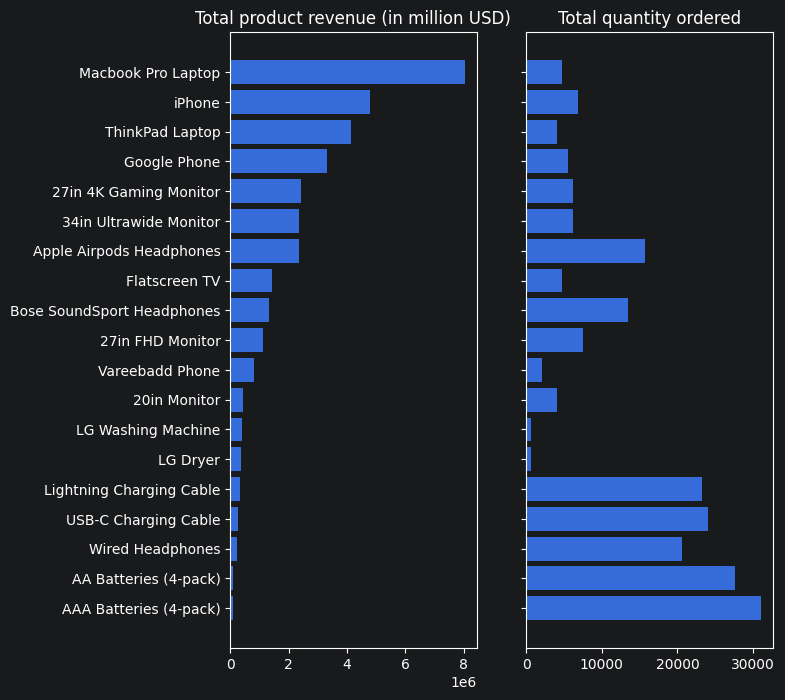

In [94]:
# fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 8), sharey="row")

sales_per_product.sort_values(by="Total_Revenue", inplace=True)
products = sales_per_product.index

total_revenue = sales_per_product.Total_Revenue
sold_quantity = sales_per_product.Quantity_Ordered

ax1.barh(products, total_revenue)
ax1.set_title("Total product revenue (in million USD)")

ax2.barh(products, sold_quantity)
ax2.set_title("Total quantity ordered")

plt.show()

#### Zadatak Viz_2: Linijski plot sa dve skale

Izračunate vrednosti za ukupnu prodaju i ukupnu ostvarenu zaradu po proizvodu možemo predstaviti i na jednom plotu, koristeći različite skale za vrednosti predstavljene na y-osi. Na primer, skala na levoj strani plota da predstavlja ostvareni prihod po proizvodu, a skala na desnoj strani da prikazuje ukupan ostvaren obim prodaje po proizvodu.  

[Ovaj primer](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/two_scales.html#sphx-glr-gallery-subplots-axes-and-figures-two-scales-py) iz matplotlib dokumentacije pokazuje kako izgleda i kako se može kreirati linijski plot sa dve različite skale na y-osi. 

Po uzoru na dati primer, potrebno je kreirati plot za tekući zadatak, odnosno prikaz izračunatih vrednosti za ukupnu prodaju i ukupnu ostvarenu zaradu po proizvodu

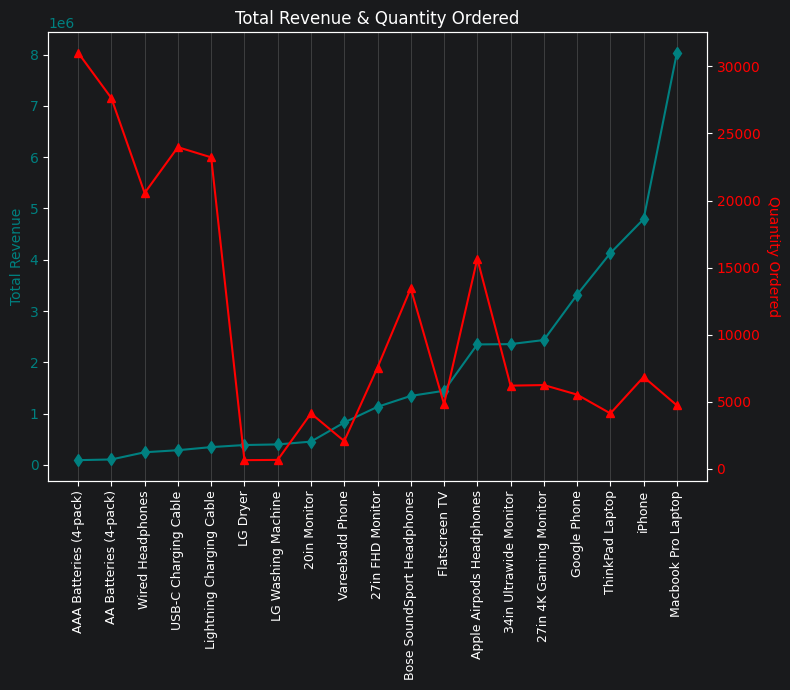

In [131]:
x = sales_per_product.index

y1 = sales_per_product.Total_Revenue
y2 = sales_per_product.Quantity_Ordered

fig, ax1 = plt.subplots(figsize=(8, 7))

color = "teal"

ax1.plot(x, y1, color=color, marker="d")
ax1.set_title("Total Revenue & Quantity Ordered")
ax1.tick_params(axis="x", labelrotation=90, labelsize=9)
ax1.tick_params(axis="y", labelcolor=color)
ax1.set_ylabel("Total Revenue", color=color)

ax1.grid(visible=True, axis="x", color="gray", alpha=0.5)

color = "red"

ax2 = ax1.twinx()

ax2.plot(x, y2, color=color, marker="^")
ax2.tick_params(axis="y", labelcolor=color)
ax2.set_ylabel("Quantity Ordered", color=color, rotation=-90, va="bottom")

fig.tight_layout()

plt.show()

### Zadatak 5. Pregled ostvarenog prihoda od prodaje po proizvodima i gradovima

Podatke možemo grupisati na osnovu više od jednog atributa (kolone). U ovom slučaju, izvršićemo grupisanje na osnovu proizvoda i grada iz koga je porudžbina stigla, i izračunati ukupan prihod za svaki proizvod u svakom gradu:

In [95]:
sales_per_city_product = sales.groupby(["Product", "Purchase_City"]).Total_Revenue.sum()
sales_per_city_product

Product       Purchase_City     
20in Monitor  Atlanta (GA)            37616.58
              Austin (TX)             25297.70
              Boston (MA)             43336.06
              Dallas (TX)             37726.57
              Los Angeles (CA)        72373.42
                                       ...    
iPhone        New York City (NY)     616700.00
              Portland (ME)           55300.00
              Portland (OR)          259700.00
              San Francisco (CA)    1162700.00
              Seattle (WA)           382200.00
Name: Total_Revenue, Length: 190, dtype: float64

Primetite da smo kao rezultat dobili pandas seriju sa dva indeksa - `Product` i `Purchase_City`:

In [96]:
sales_per_city_product.info()

<class 'pandas.Series'>
MultiIndex: 190 entries, ('20in Monitor', 'Atlanta (GA)') to ('iPhone', 'Seattle (WA)')
Series name: Total_Revenue
Non-Null Count  Dtype  
--------------  -----  
190 non-null    float64
dtypes: float64(1)
memory usage: 2.7+ KB


In [97]:
sales_per_city_product.index

MultiIndex([('20in Monitor',       'Atlanta (GA)'),
            ('20in Monitor',        'Austin (TX)'),
            ('20in Monitor',        'Boston (MA)'),
            ('20in Monitor',        'Dallas (TX)'),
            ('20in Monitor',   'Los Angeles (CA)'),
            ('20in Monitor', 'New York City (NY)'),
            ('20in Monitor',      'Portland (ME)'),
            ('20in Monitor',      'Portland (OR)'),
            ('20in Monitor', 'San Francisco (CA)'),
            ('20in Monitor',       'Seattle (WA)'),
            ...
            (      'iPhone',       'Atlanta (GA)'),
            (      'iPhone',        'Austin (TX)'),
            (      'iPhone',        'Boston (MA)'),
            (      'iPhone',        'Dallas (TX)'),
            (      'iPhone',   'Los Angeles (CA)'),
            (      'iPhone', 'New York City (NY)'),
            (      'iPhone',      'Portland (ME)'),
            (      'iPhone',      'Portland (OR)'),
            (      'iPhone', 'San Francisco (CA)

Ovakvu seriju možemo transformisati u data frame uz pomoć `unstack()` metode:

In [98]:
dtf = sales_per_city_product.unstack()
dtf

Purchase_City,Atlanta (GA),Austin (TX),Boston (MA),Dallas (TX),Los Angeles (CA),New York City (NY),Portland (ME),Portland (OR),San Francisco (CA),Seattle (WA)
Product,,,,,,,,,,
20in Monitor,37616.58,25297.70,43336.06,37726.57,72373.42,61594.40,6489.41,24087.81,109990.00,35636.76
27in 4K Gaming Monitor,192265.07,124016.82,263243.25,187585.19,391159.97,328371.58,33149.15,136106.51,569385.40,209814.62
27in FHD Monitor,88194.12,53996.40,119542.03,88044.13,183437.77,160789.28,17098.86,62395.84,272081.86,86844.21
34in Ultrawide Monitor,183155.18,124636.72,254973.29,194554.88,362890.45,329831.32,28879.24,124256.73,549465.54,202914.66
AA Batteries (4-pack),8421.12,5468.16,11581.44,8682.24,17041.92,13939.20,1493.76,5952.00,25171.20,8367.36
AAA Batteries (4-pack),7053.41,4987.32,10348.39,7486.96,14851.33,12330.76,1070.42,5148.78,22149.92,7313.54
Apple Airpods Headphones,189900.00,133050.00,247950.00,179100.00,370950.00,314700.00,34950.00,129900.00,559950.00,188700.00
Bose SoundSport Headphones,108389.16,70692.93,141585.84,106289.37,212478.75,179382.06,17998.20,70892.91,331666.83,106189.38
Flatscreen TV,122100.00,72600.00,166200.00,126000.00,218100.00,188400.00,18600.00,75000.00,346200.00,112500.00


In [99]:
dtf.info()

<class 'pandas.DataFrame'>
Index: 19 entries, 20in Monitor to iPhone
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Atlanta (GA)        19 non-null     float64
 1   Austin (TX)         19 non-null     float64
 2   Boston (MA)         19 non-null     float64
 3   Dallas (TX)         19 non-null     float64
 4   Los Angeles (CA)    19 non-null     float64
 5   New York City (NY)  19 non-null     float64
 6   Portland (ME)       19 non-null     float64
 7   Portland (OR)       19 non-null     float64
 8   San Francisco (CA)  19 non-null     float64
 9   Seattle (WA)        19 non-null     float64
dtypes: float64(10)
memory usage: 2.2+ KB


S obzirom da je ovakav prikaz ostvarene prodaje vrlo nepregledan, predstavićemo ga vizuelno, koristeći `heatmap`. 

Korisne smernice za kreiranje heatmap-e date su, na primer, [ovde](https://python-charts.com/correlation/heatmap-matplotlib/).

Na [ovoj stranici](https://matplotlib.org/stable/users/explain/colors/colormaps.html) Matplotlib dokumentacije možete naći pregled predefinisanih kolor mapa.

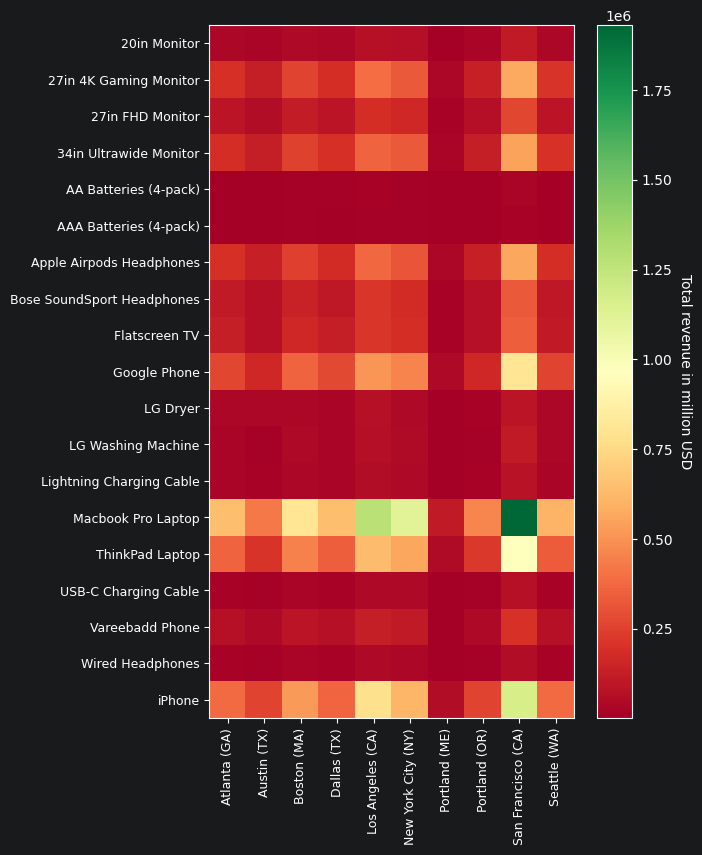

In [100]:
products = dtf.index
cities = dtf.columns

_, ax = plt.subplots(figsize=(6, 9))
hm = ax.imshow(dtf, cmap="RdYlGn")

ax.set_xticks(range(len(cities)), labels=cities)
ax.set_yticks(range(len(products)), labels=products)

ax.tick_params(axis="x", labelrotation=90, labelsize=9)
ax.tick_params(axis="y", labelsize=9)

cbar = ax.figure.colorbar(hm, ax=ax)
cbar.ax.set_ylabel("Total revenue in million USD", rotation=-90, va="bottom")

plt.show()

#### Zadatak Viz_3: Heatmap sa dodatim numeričkim vrednostima

Unaprediti prethodni heatmap plot, time što ćete u svakoj ćeliji heatmap-e prikazati ukupan ostvareni prihod od prodaje za svaku kombinaciju grad - proizvod, izražen u milionima USA dolara  

Dodatne smernice za kreiranje heatmap-e, uključujući neke složenije primere, date su na [ovoj stranici](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html#sphx-glr-gallery-images-contours-and-fields-image-annotated-heatmap-py) matplotlib dokumentacije.

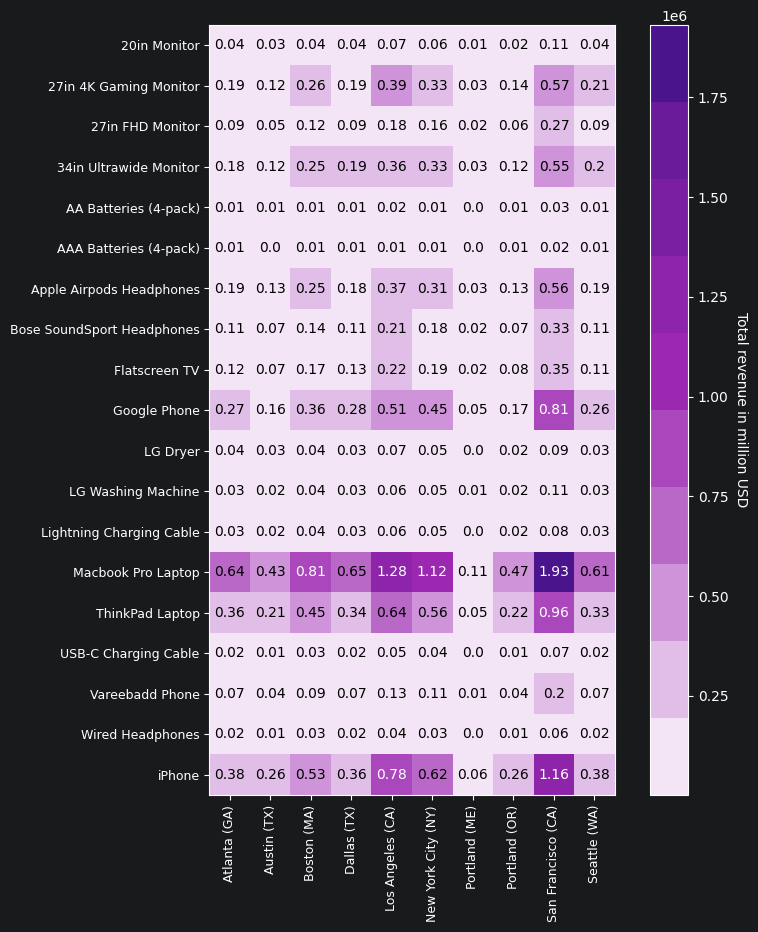

In [125]:
data = dtf.values

products = dtf.index
cities = dtf.columns

cmap = pypalettes.load_cmap("purple_material")

_, ax = plt.subplots(figsize=(9, 10))
hm = ax.imshow(dtf, cmap=cmap)

ax.set_xticks(range(len(cities)), labels=cities)
ax.set_yticks(range(len(products)), labels=products)

ax.tick_params(axis="x", labelrotation=90, labelsize=9)
ax.tick_params(axis="y", labelsize=9)

cbar = ax.figure.colorbar(hm, ax=ax)
cbar.ax.set_ylabel("Total revenue in million USD", rotation=-90, va="bottom")

for p in range(len(products)):
    for c in range(len(cities)):
        val = round(data[p, c] / 1000000, 2)
        color = "black" if val < 0.75 else "white"
        ax.text(c, p, val, va="center", ha="center", color=color)

plt.show()

#### Zadatak Viz_4: Prikazati uporedo mesečni obim narudžbina u 2019. godini za svaku državu ponaosob

Prikaz bi trebalo da bude u obliku mreže (grid) bar plotova (po jedan za svaku državu), predstavljene u dva reda i četiri kolone.
Bar plotovi bi trebalo da budu sortrani u rastućem redosledu obima prodaje, tako da prvi odgovara državi sa najmanjim ukupnim obimom prodaje, dok poslednji odgovara državi sa najvećim ukupnim obimom prodaje.

Potrebno je prvo kreirati novu kolonu koja predstavlja državu iz koje je porudžbina stigla

In [142]:
sales["State"] = sales.Purchase_City.apply(lambda cs: separate_city_and_state(cs)[1])

,Order ID,Product,Purchase Address,Quantity_Ordered,Price_Each,Order_Date,Purchase_City,Total_Revenue,Order_Month,Order_Hour,State
0,176558,USB-C Charging Cable,"917 1st St, Dallas, TX 75001",2.0,11.95,2019-04-19 08:46:00,Dallas (TX),23.90,4,8,TX
1,176559,Bose SoundSport Headphones,"682 Chestnut St, Boston, MA 02215",1.0,99.99,2019-04-07 22:30:00,Boston (MA),99.99,4,22,MA
2,176560,Google Phone,"669 Spruce St, Los Angeles, CA 90001",1.0,600.00,2019-04-12 14:38:00,Los Angeles (CA),600.00,4,14,CA
3,176560,Wired Headphones,"669 Spruce St, Los Angeles, CA 90001",1.0,11.99,2019-04-12 14:38:00,Los Angeles (CA),11.99,4,14,CA
4,176561,Wired Headphones,"333 8th St, Los Angeles, CA 90001",1.0,11.99,2019-04-30 09:27:00,Los Angeles (CA),11.99,4,9,CA


Zatim je potrebno odrediti ukupan obim narudžbina za svaku državu u 2019. god., kako bi to iskoristili kasnije za sortiranje bar plotova u okviru mreže (grid):

In [152]:
sales_per_state = sales.groupby("State").Quantity_Ordered.sum().sort_values()
sales_per_state

State
ME     2750.0
OR    11303.0
WA    16553.0
GA    16602.0
MA    22528.0
TX    27883.0
NY    27932.0
CA    83528.0
Name: Quantity_Ordered, dtype: float64

In [154]:
states_ordered = sales_per_state.index.tolist()
states_ordered

['ME', 'OR', 'WA', 'GA', 'MA', 'TX', 'NY', 'CA']

Sledeći korak je da se za svaku državu ponaosob izračuna obim prodaje na mesečnom nivou:

In [177]:
sales_dict = dict()
for state in states_ordered:
    sales_dict[state] = sales.loc[sales["State"] == state,].groupby("Order_Month").Quantity_Ordered.sum()

sales_dict["CA"]

Order_Month
1      4377.0
2      5403.0
3      6780.0
4      8373.0
5      7328.0
6      6139.0
7      6495.0
8      5267.0
9      5206.0
10     9035.0
11     7960.0
12    11165.0
Name: Quantity_Ordered, dtype: float64

Konačno, prikazati mesečne kupovine za svaku državu u formi mreže bar plotova:

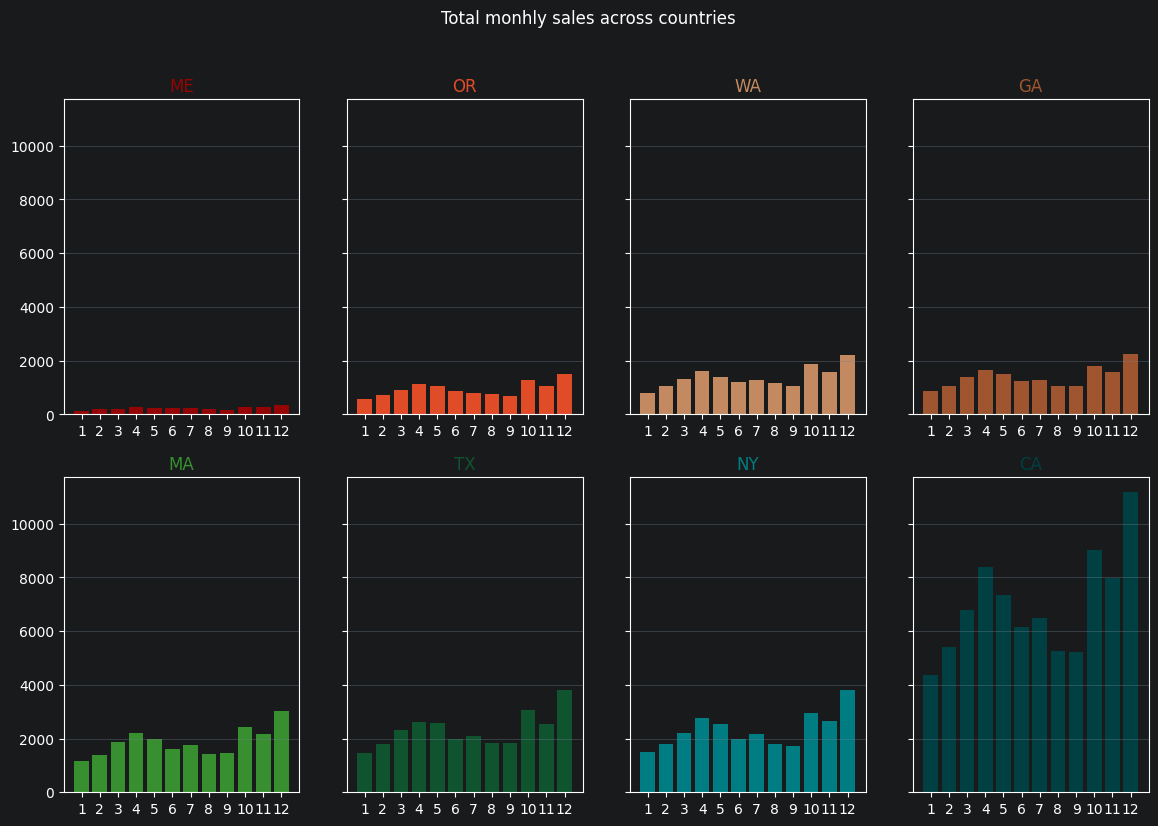

In [176]:
fig, axes = plt.subplots(2, 4, figsize=(14, 9), sharey="all")

x = range(1, 13)

cmap = pypalettes.load_cmap("Abbott")

for i, state in enumerate(states_ordered):
    y = sales_dict[state]
    row, col = i // 4, i % 4

    axes[row, col].bar(x, y, color=cmap(i))
    axes[row, col].set_xticks(x)
    axes[row, col].set_title(state, color=cmap(i))
    axes[row, col].grid(visible=True, axis="y", color="slategray", alpha=0.5)

fig.suptitle("Total monhly sales across countries")

plt.show()